
# Paso 05 · Análisis y diseño de características

Este notebook analiza **qué información conocida hasta el mes \(t\)** puede ayudar a anticipar la clase de intensidad de precipitación del mes siguiente:

\[
X_{z,t} \rightarrow Y_{z,t+1}
\]

La definición del target ya está congelada en el Paso 04:

- **Baja:** \(Rx5day_{t+1} < Q33_{global}\)
- **Media:** \(Q33_{global} \le Rx5day_{t+1} < Q66_{global}\)
- **Alta:** \(Rx5day_{t+1} \ge Q66_{global}\)

## Reglas metodológicas de este paso

1. **Las decisiones de características se toman únicamente con el split `entrenamiento`.**
2. `validacion_temporal`, `prueba_temporal` y los holdouts no participan en la selección.
3. `target_rx5day_mm` se usa solo como variable auxiliar de análisis, **nunca como predictor**.
4. No se entrenan todavía los cinco clasificadores finales.
5. Los lags se estudian de 0 a 12 meses para evitar volver a crear retrasos arbitrariamente.
6. Las variables de calidad, identificadores y columnas futuras se excluyen por diseño antes de cualquier análisis.


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()
while not (BASE_DIR / "zonas_era5_ecuador.csv").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "zonas_era5_ecuador.csv").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")

INPUT_FILE = (
    BASE_DIR
    / "datos"
    / "modelado"
    / "dataset_objetivo_mensual.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "resultados"
    / "analisis_caracteristicas"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CLASS_ORDER = ["Baja", "Media", "Alta"]

print(f"Entrada: {INPUT_FILE}")
print(f"Salidas: {OUTPUT_DIR}")


Entrada: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\datos\modelado\dataset_objetivo_mensual.csv
Salidas: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\analisis_caracteristicas



## 1. Carga del dataset supervisado

Aunque el archivo contiene todos los splits para mantener una única fuente reproducible, **este notebook solo utilizará `entrenamiento` para decidir características**.


In [2]:

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró {INPUT_FILE}. Ejecuta primero el Paso 04."
    )

df = pd.read_csv(INPUT_FILE, encoding="utf-8-sig")

df["period_start"] = pd.to_datetime(df["period_start"])
df["target_period_start"] = pd.to_datetime(df["target_period_start"])

df = (
    df.sort_values(["zone_id", "period_start"])
      .reset_index(drop=True)
)

train = df[df["split"] == "entrenamiento"].copy()

print(f"Dataset total: {len(df):,} filas")
print(f"Entrenamiento usado en Paso 05: {len(train):,} filas")
print(f"Zonas de entrenamiento: {train['zone_id'].nunique()}")
print("\nClases en entrenamiento:")
print(train["target_amenaza"].value_counts().reindex(CLASS_ORDER))


Dataset total: 6,285 filas
Entrenamiento usado en Paso 05: 3,876 filas
Zonas de entrenamiento: 12

Clases en entrenamiento:
target_amenaza
Baja     1279
Media    1278
Alta     1319
Name: count, dtype: int64



## 2. Separación por diseño: qué puede ser predictor y qué no

Antes de calcular correlaciones o importancia estadística, retiramos columnas que **no deberían competir como features**.

### Se excluyen

- `target_amenaza`: es la etiqueta.
- `target_rx5day_mm`: es el valor futuro que origina la etiqueta.
- `target_period_start`: identifica el mes futuro.
- `split`, `rol`: son metadatos experimentales.
- identificadores textuales (`zone_id`, `ciudad`, `provincia`): podrían memorizar zonas y no ayudan a generalizar al holdout espacial.
- columnas de control de calidad: todas son constantes o indicadores de completitud del procesamiento.
- `period`, `period_start`, `year`: identifican tiempo histórico; no queremos que el modelo memorice una época.
- `amenaza_mes`: es una discretización determinística del `rx5day_mm` actual. Se reservará para el **baseline de persistencia**, no como feature primaria.
- `month`, `month_sin`, `month_cos`: se reemplazan por el **mes objetivo \(t+1\)**, que es conocido al momento de predecir y está mejor alineado con el problema.

La región, latitud y longitud sí permanecen como contexto geográfico potencialmente generalizable.


In [3]:

EXCLUDED_BY_DESIGN = {
    "period": "Identificador temporal textual.",
    "period_start": "Fecha de entrada; se evita memorizar época.",
    "year": "Se evita usar tendencia temporal como atajo.",
    "month": "Se reemplaza por mes objetivo.",
    "month_sin": "Se reemplaza por codificación cíclica del mes objetivo.",
    "month_cos": "Se reemplaza por codificación cíclica del mes objetivo.",
    "expected_days_in_month": "Control de completitud.",
    "days_available": "Control de completitud.",
    "is_complete_month": "Control de completitud.",
    "days_with_incomplete_precip_hours": "Control de calidad.",
    "days_with_incomplete_instant_hours": "Control de calidad.",
    "zone_id": "Identificador de zona; perjudica generalización a zonas no vistas.",
    "ciudad": "Identificador textual de zona.",
    "provincia": "Identificador geográfico demasiado específico.",
    "rol": "Metadato experimental.",
    "amenaza_mes": "Derivación determinística de Rx5day actual; se reserva para baseline de persistencia.",
    "target_period_start": "Información del objetivo; solo se usa para crear mes objetivo conocido.",
    "target_rx5day_mm": "Valor futuro. Prohibido como predictor.",
    "target_amenaza": "Etiqueta.",
    "split": "Metadato experimental.",
}

excluded_report = pd.DataFrame(
    [{"columna": k, "motivo": v} for k, v in EXCLUDED_BY_DESIGN.items()]
)

excluded_report.to_csv(
    OUTPUT_DIR / "caracteristicas_excluidas_por_diseno.csv",
    index=False,
    encoding="utf-8-sig",
)

excluded_report


,columna,motivo
0,period,Identificador temporal textual.
1,period_start,Fecha de entrada; se evita memorizar época.
2,year,Se evita usar tendencia temporal como atajo.
3,month,Se reemplaza por mes objetivo.
4,month_sin,Se reemplaza por codificación cíclica del mes ...
5,month_cos,Se reemplaza por codificación cíclica del mes ...
6,expected_days_in_month,Control de completitud.
7,days_available,Control de completitud.
8,is_complete_month,Control de completitud.
9,days_with_incomplete_precip_hours,Control de calidad.



## 3. Variables derivadas conocidas al momento de la predicción

El mes que queremos predecir es conocido. Si la entrada es septiembre, sabemos que el objetivo será octubre.

Por eso creamos:

\[
\sin\left(2\pi\frac{mes_{t+1}}{12}\right), \quad
\cos\left(2\pi\frac{mes_{t+1}}{12}\right)
\]

Esto representa la estacionalidad sin introducir una falsa distancia lineal entre diciembre y enero.


In [4]:

for frame in (df, train):
    frame["target_month"] = frame["target_period_start"].dt.month
    frame["target_month_sin"] = np.sin(
        2 * np.pi * frame["target_month"] / 12
    )
    frame["target_month_cos"] = np.cos(
        2 * np.pi * frame["target_month"] / 12
    )

BASE_NUMERIC_FEATURES = [
    "prcptot_mm",
    "rx1day_mm",
    "rx5day_mm",
    "max_1h_mm",
    "max_3h_mm",
    "max_6h_mm",
    "wet_days",
    "r10mm_days",
    "r20mm_days",
    "sdii_mm_per_wet_day",
    "cwd_days",
    "cdd_days",
    "temperature_mean_c",
    "temperature_max_c",
    "temperature_min_c",
    "dewpoint_mean_c",
    "relative_humidity_mean_pct",
    "wind_mean_ms",
    "wind_max_ms",
    "surface_pressure_mean_hpa",
    "latitud_solicitada",
    "longitud_solicitada",
    "target_month_sin",
    "target_month_cos",
]

CATEGORICAL_CANDIDATES = [
    "region",
]

missing = [
    column
    for column in BASE_NUMERIC_FEATURES + CATEGORICAL_CANDIDATES
    if column not in train.columns
]

if missing:
    raise ValueError(f"Faltan columnas candidatas: {missing}")

inventory = pd.DataFrame({
    "columna": BASE_NUMERIC_FEATURES + CATEGORICAL_CANDIDATES,
    "tipo": (
        ["numerica"] * len(BASE_NUMERIC_FEATURES)
        + ["categorica"] * len(CATEGORICAL_CANDIDATES)
    ),
})

inventory.to_csv(
    OUTPUT_DIR / "inventario_caracteristicas_candidatas.csv",
    index=False,
    encoding="utf-8-sig",
)

inventory


,columna,tipo
0,prcptot_mm,numerica
1,rx1day_mm,numerica
2,rx5day_mm,numerica
3,max_1h_mm,numerica
4,max_3h_mm,numerica
5,max_6h_mm,numerica
6,wet_days,numerica
7,r10mm_days,numerica
8,r20mm_days,numerica
9,sdii_mm_per_wet_day,numerica



## 4. Varianza y cardinalidad

Una característica constante o casi constante no aporta información útil. Este chequeo se hace **solo con entrenamiento**.


In [5]:

variance_rows = []

for column in BASE_NUMERIC_FEATURES:
    series = train[column]
    variance_rows.append({
        "caracteristica": column,
        "n_unicos": series.nunique(dropna=True),
        "varianza": series.var(),
        "porcentaje_nulos": 100 * series.isna().mean(),
    })

variance_report = pd.DataFrame(variance_rows).sort_values(
    ["n_unicos", "varianza"],
    ascending=[True, True],
)

variance_report.to_csv(
    OUTPUT_DIR / "varianza_cardinalidad.csv",
    index=False,
    encoding="utf-8-sig",
)

variance_report


,caracteristica,n_unicos,varianza,porcentaje_nulos
23,target_month_cos,11,0.499348,0.0
22,target_month_sin,11,0.500901,0.0
21,longitud_solicitada,12,0.829756,0.0
20,latitud_solicitada,12,1.613976,0.0
8,r20mm_days,23,8.145768,0.0
7,r10mm_days,29,32.386659,0.0
11,cdd_days,32,24.192684,0.0
6,wet_days,32,62.316552,0.0
10,cwd_days,32,94.911370,0.0
13,temperature_max_c,3844,21.327608,0.0



## 5. Asociación individual con el objetivo

No usaremos este ranking para eliminar automáticamente variables. Sirve para saber si una característica, por sí sola, contiene señal.

Calculamos dos perspectivas:

- **Información mutua con `target_amenaza`**: captura relaciones potencialmente no lineales con la clase.
- **Spearman con `target_rx5day_mm`**: mide asociación monotónica con la magnitud física futura.

Todo se calcula exclusivamente sobre entrenamiento.


In [6]:

label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(train["target_amenaza"])

X_base = train[BASE_NUMERIC_FEATURES].copy()

if X_base.isna().any().any():
    raise ValueError(
        "Existen nulos en características base. "
        "Revísalos antes de calcular información mutua."
    )

mi = mutual_info_classif(
    X_base,
    y_class,
    random_state=RANDOM_STATE,
)

spearman_target = (
    train[BASE_NUMERIC_FEATURES + ["target_rx5day_mm"]]
    .corr(method="spearman")["target_rx5day_mm"]
    .drop("target_rx5day_mm")
)

association_report = pd.DataFrame({
    "caracteristica": BASE_NUMERIC_FEATURES,
    "mutual_information_target_clase": mi,
    "spearman_target_rx5day": [
        spearman_target.loc[column]
        for column in BASE_NUMERIC_FEATURES
    ],
})

association_report["abs_spearman_target_rx5day"] = (
    association_report["spearman_target_rx5day"].abs()
)

association_report = association_report.sort_values(
    [
        "mutual_information_target_clase",
        "abs_spearman_target_rx5day",
    ],
    ascending=False,
)

association_report.to_csv(
    OUTPUT_DIR / "asociacion_base_con_target.csv",
    index=False,
    encoding="utf-8-sig",
)

association_report


,caracteristica,mutual_information_target_clase,spearman_target_rx5day,abs_spearman_target_rx5day
0,prcptot_mm,0.297862,0.728680,0.728680
19,surface_pressure_mean_hpa,0.288963,-0.157580,0.157580
7,r10mm_days,0.282404,0.694023,0.694023
4,max_3h_mm,0.242805,0.665703,0.665703
9,sdii_mm_per_wet_day,0.242441,0.673272,0.673272
2,rx5day_mm,0.239812,0.703606,0.703606
3,max_1h_mm,0.228151,0.654117,0.654117
5,max_6h_mm,0.222542,0.663179,0.663179
1,rx1day_mm,0.219374,0.670909,0.670909
17,wind_mean_ms,0.217913,-0.610319,0.610319


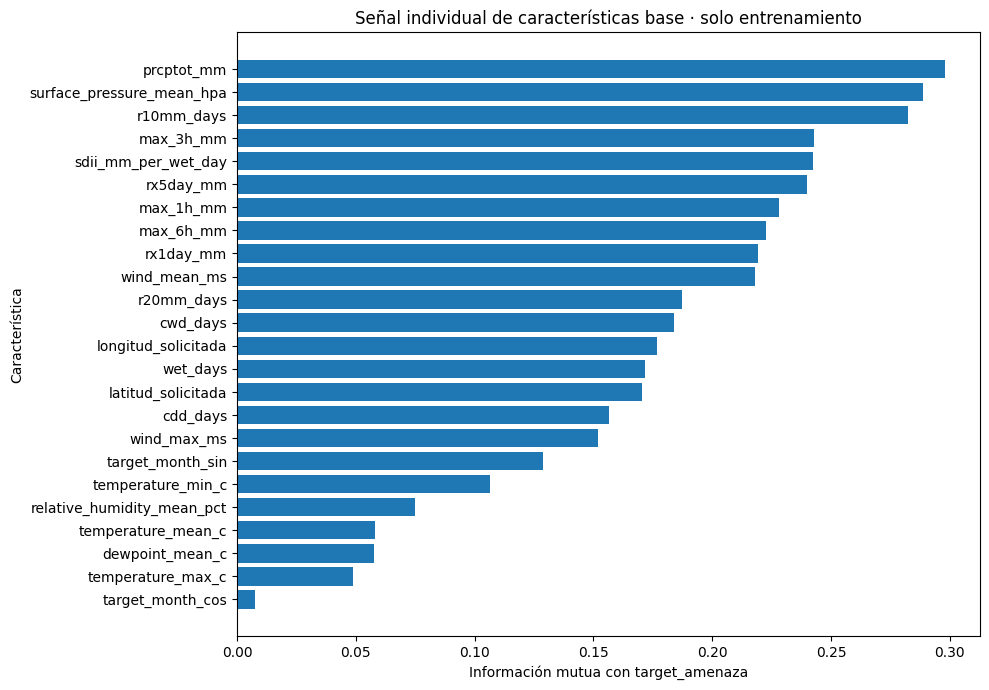

In [7]:

plt.figure(figsize=(10, 7))
plot_data = association_report.sort_values(
    "mutual_information_target_clase",
    ascending=True,
)
plt.barh(
    plot_data["caracteristica"],
    plot_data["mutual_information_target_clase"],
)
plt.xlabel("Información mutua con target_amenaza")
plt.ylabel("Característica")
plt.title("Señal individual de características base · solo entrenamiento")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "01_informacion_mutua_base.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()



## 6. Redundancia y multicolinealidad

Muchas variables meteorológicas describen fenómenos relacionados. Por ejemplo, `max_1h`, `max_3h` y `max_6h` pueden ser muy similares.

Calculamos correlación de Spearman entre características numéricas y listamos pares con:

\[
|\rho| \ge 0.90
\]

Esto **no elimina nada automáticamente**. El objetivo es identificar grupos redundantes para decidir después qué representación conservar.


In [8]:

corr_matrix = train[BASE_NUMERIC_FEATURES].corr(method="spearman")

high_corr_rows = []

for i, col_a in enumerate(BASE_NUMERIC_FEATURES):
    for col_b in BASE_NUMERIC_FEATURES[i + 1:]:
        rho = corr_matrix.loc[col_a, col_b]

        if abs(rho) >= 0.90:
            high_corr_rows.append({
                "caracteristica_1": col_a,
                "caracteristica_2": col_b,
                "spearman": rho,
                "abs_spearman": abs(rho),
            })

high_corr_report = pd.DataFrame(high_corr_rows)

if not high_corr_report.empty:
    high_corr_report = high_corr_report.sort_values(
        "abs_spearman",
        ascending=False,
    )

high_corr_report.to_csv(
    OUTPUT_DIR / "pares_alta_correlacion.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    f"Pares con |Spearman| >= 0.90: "
    f"{len(high_corr_report)}"
)

high_corr_report


Pares con |Spearman| >= 0.90: 20


,caracteristica_1,caracteristica_2,spearman,abs_spearman
11,max_3h_mm,max_6h_mm,0.982656,0.982656
16,temperature_mean_c,temperature_min_c,0.972222,0.972222
5,rx1day_mm,max_6h_mm,0.964118,0.964118
18,temperature_min_c,dewpoint_mean_c,0.962862,0.962862
9,max_1h_mm,max_3h_mm,0.959511,0.959511
1,prcptot_mm,r10mm_days,0.954820,0.954820
17,temperature_mean_c,dewpoint_mean_c,0.952590,0.952590
0,prcptot_mm,rx5day_mm,0.944580,0.944580
4,rx1day_mm,max_3h_mm,0.937342,0.937342
13,wet_days,cdd_days,-0.933395,0.933395


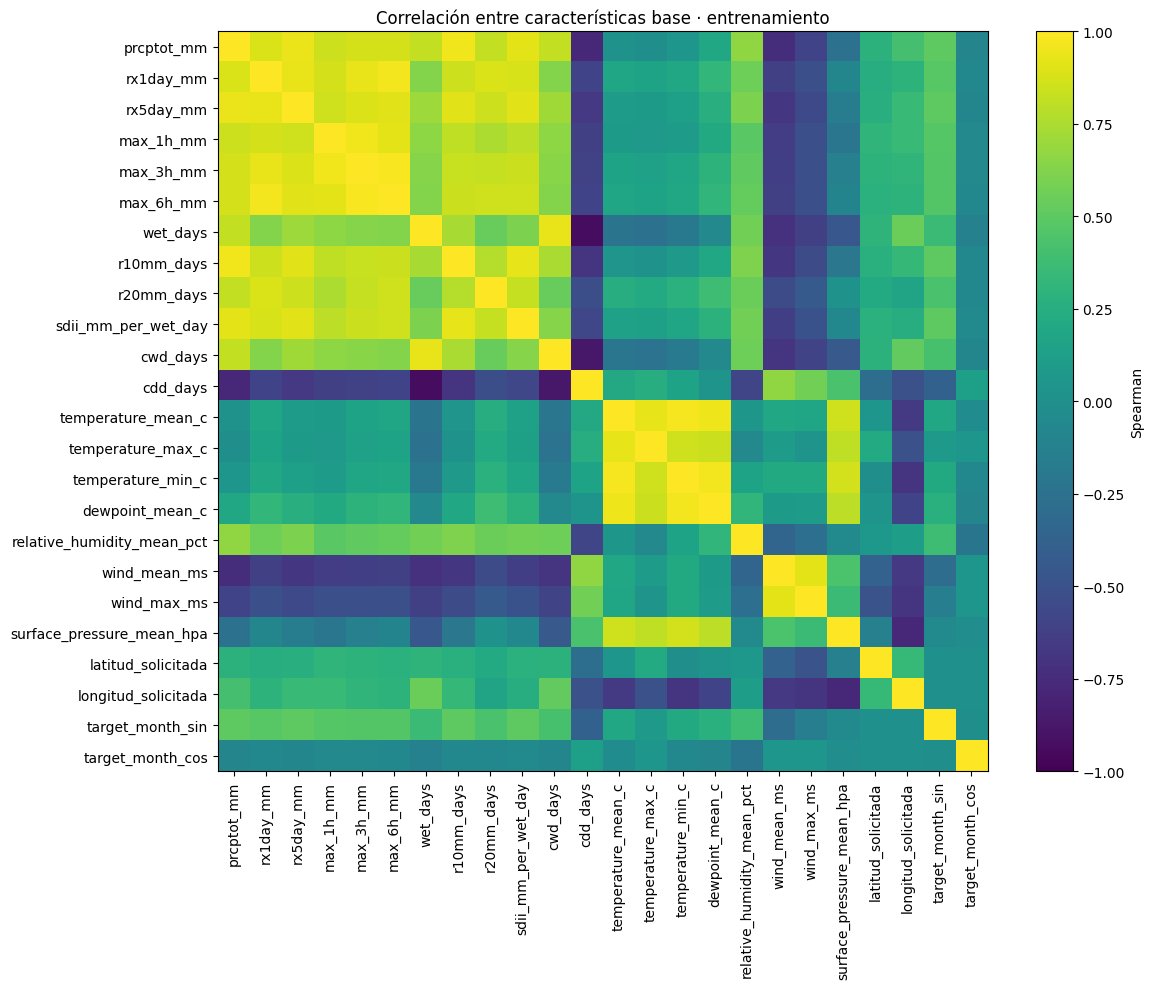

In [9]:

plt.figure(figsize=(12, 10))
image = plt.imshow(
    corr_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
)
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
)
plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index,
)
plt.colorbar(image, label="Spearman")
plt.title("Correlación entre características base · entrenamiento")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "02_matriz_correlacion_spearman.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()



## 7. Diferencias de las variables según la clase futura

Este resumen permite ver si los valores actuales cambian de forma sistemática cuando el próximo mes termina siendo `Baja`, `Media` o `Alta`.

Se reportan medianas para ser menos sensibles a extremos meteorológicos.


In [10]:

class_medians = (
    train.groupby("target_amenaza", observed=True)[BASE_NUMERIC_FEATURES]
    .median()
    .reindex(CLASS_ORDER)
    .T
    .reset_index()
    .rename(columns={"index": "caracteristica"})
)

class_medians.to_csv(
    OUTPUT_DIR / "medianas_caracteristicas_por_clase.csv",
    index=False,
    encoding="utf-8-sig",
)

class_medians


target_amenaza,caracteristica,Baja,Media,Alta
0,prcptot_mm,65.572160,1.591919e+02,2.649896e+02
1,rx1day_mm,9.857836,1.908211e+01,3.214447e+01
2,rx5day_mm,24.656907,5.647929e+01,8.591575e+01
3,max_1h_mm,1.672831,3.684294e+00,5.336613e+00
4,max_3h_mm,3.845662,8.010406e+00,1.228318e+01
5,max_6h_mm,5.915800,1.212227e+01,1.970958e+01
6,wet_days,18.000000,2.700000e+01,2.900000e+01
7,r10mm_days,0.000000,4.000000e+00,9.000000e+00
8,r20mm_days,0.000000,0.000000e+00,2.000000e+00
9,sdii_mm_per_wet_day,4.026755,6.218204e+00,9.322063e+00



## 8. Análisis temporal de lags

Aquí evitamos repetir el error anterior de crear todos los lags de todas las variables porque sí.

Para un conjunto representativo de indicadores analizamos:

\[
lag0=t,\ lag1=t-1,\ldots,lag12=t-12
\]

Para cada variable y cada lag calculamos:

- información mutua con la clase futura;
- Spearman con `target_rx5day_mm`.

### Nota importante sobre `lag11`

Como el objetivo es \(t+1\), el valor en \(t-11\) corresponde al **mismo mes calendario del año anterior al mes objetivo**. Por eso `lag11` merece atención especial, pero no se incluirá automáticamente si los datos no muestran señal.


In [11]:

LAG_SOURCE_FEATURES = [
    "prcptot_mm",
    "rx1day_mm",
    "rx5day_mm",
    "wet_days",
    "r10mm_days",
    "r20mm_days",
    "sdii_mm_per_wet_day",
    "cwd_days",
    "cdd_days",
    "temperature_mean_c",
    "dewpoint_mean_c",
    "relative_humidity_mean_pct",
    "wind_mean_ms",
    "surface_pressure_mean_hpa",
]

MAX_LAG = 12

lag_source = df[
    [
        "zone_id",
        "period_start",
        "split",
        "target_amenaza",
        "target_rx5day_mm",
    ]
    + LAG_SOURCE_FEATURES
].copy()

lag_source = lag_source.sort_values(
    ["zone_id", "period_start"]
).reset_index(drop=True)

lag_analysis_rows = []

for feature in LAG_SOURCE_FEATURES:
    feature_frame = lag_source[
        [
            "zone_id",
            "period_start",
            "split",
            "target_amenaza",
            "target_rx5day_mm",
            feature,
        ]
    ].copy()

    for lag in range(MAX_LAG + 1):
        column = f"{feature}__lag{lag}"

        if lag == 0:
            feature_frame[column] = feature_frame[feature]
        else:
            feature_frame[column] = (
                feature_frame
                .groupby("zone_id")[feature]
                .shift(lag)
            )

    lag_columns = [
        f"{feature}__lag{lag}"
        for lag in range(MAX_LAG + 1)
    ]

    # Todas las comparaciones de esta variable usan exactamente las
    # mismas filas, para que los lags sean comparables entre sí.
    comparable = feature_frame[
        feature_frame["split"] == "entrenamiento"
    ].dropna(
        subset=lag_columns
        + ["target_amenaza", "target_rx5day_mm"]
    )

    y_lag = label_encoder.transform(
        comparable["target_amenaza"]
    )

    for lag, column in enumerate(lag_columns):
        x = comparable[[column]]

        mi_value = mutual_info_classif(
            x,
            y_lag,
            random_state=RANDOM_STATE,
        )[0]

        rho = comparable[
            [column, "target_rx5day_mm"]
        ].corr(method="spearman").iloc[0, 1]

        lag_analysis_rows.append({
            "variable": feature,
            "lag": lag,
            "referencia_temporal": (
                "t"
                if lag == 0
                else f"t-{lag}"
            ),
            "n_comparable": len(comparable),
            "mutual_information_target_clase": mi_value,
            "spearman_target_rx5day": rho,
            "abs_spearman_target_rx5day": abs(rho),
            "es_mismo_mes_anio_anterior_del_objetivo": (
                lag == 11
            ),
        })

lag_report = pd.DataFrame(lag_analysis_rows)

lag_report.to_csv(
    OUTPUT_DIR / "analisis_lags_0_12.csv",
    index=False,
    encoding="utf-8-sig",
)

lag_report.head(20)


,variable,lag,referencia_temporal,n_comparable,mutual_information_target_clase,spearman_target_rx5day,abs_spearman_target_rx5day,es_mismo_mes_anio_anterior_del_objetivo
0,prcptot_mm,0,t,3732,0.301158,0.730405,0.730405,False
1,prcptot_mm,1,t-1,3732,0.131881,0.527000,0.527000,False
2,prcptot_mm,2,t-2,3732,0.073253,0.333694,0.333694,False
3,prcptot_mm,3,t-3,3732,0.008680,0.180176,0.180176,False
4,prcptot_mm,4,t-4,3732,0.002467,0.066601,0.066601,False
5,prcptot_mm,5,t-5,3732,0.013836,0.033365,0.033365,False
6,prcptot_mm,6,t-6,3732,0.020192,0.072701,0.072701,False
7,prcptot_mm,7,t-7,3732,0.031465,0.162036,0.162036,False
8,prcptot_mm,8,t-8,3732,0.048628,0.300297,0.300297,False
9,prcptot_mm,9,t-9,3732,0.134106,0.467442,0.467442,False



## 9. Resumen de lags candidatos

Para cada variable se muestran:

- el lag con mayor información mutua;
- el lag con mayor asociación absoluta con `target_rx5day_mm`;
- las métricas específicas de `lag0`, `lag1`, `lag2` y `lag11`.

Este reporte **no constituye aún la selección final**. Es la evidencia que usaremos para decidir qué lags vale la pena construir en el siguiente paso.


In [12]:

lag_summary_rows = []

for feature, group in lag_report.groupby("variable"):
    best_mi = group.loc[
        group["mutual_information_target_clase"].idxmax()
    ]

    best_spearman = group.loc[
        group["abs_spearman_target_rx5day"].idxmax()
    ]

    row = {
        "variable": feature,
        "mejor_lag_mi": int(best_mi["lag"]),
        "mejor_mi": best_mi["mutual_information_target_clase"],
        "mejor_lag_abs_spearman": int(best_spearman["lag"]),
        "mejor_abs_spearman": best_spearman["abs_spearman_target_rx5day"],
    }

    for lag in [0, 1, 2, 11]:
        lag_row = group[group["lag"] == lag].iloc[0]
        row[f"mi_lag{lag}"] = lag_row[
            "mutual_information_target_clase"
        ]
        row[f"abs_spearman_lag{lag}"] = lag_row[
            "abs_spearman_target_rx5day"
        ]

    lag_summary_rows.append(row)

lag_summary = (
    pd.DataFrame(lag_summary_rows)
    .sort_values("mejor_mi", ascending=False)
)

lag_summary.to_csv(
    OUTPUT_DIR / "resumen_lags_candidatos.csv",
    index=False,
    encoding="utf-8-sig",
)

lag_summary


,variable,mejor_lag_mi,mejor_mi,mejor_lag_abs_spearman,mejor_abs_spearman,mi_lag0,abs_spearman_lag0,mi_lag1,abs_spearman_lag1,mi_lag2,abs_spearman_lag2,mi_lag11,abs_spearman_lag11
3,prcptot_mm,0,0.301158,0,0.730405,0.301158,0.730405,0.131881,0.527000,0.073253,0.333694,0.277411,0.705777
10,surface_pressure_mean_hpa,0,0.284670,0,0.151816,0.284670,0.151816,0.263428,0.146998,0.212904,0.135068,0.264636,0.144867
8,rx5day_mm,11,0.262893,0,0.705669,0.242828,0.705669,0.134578,0.513308,0.054130,0.326348,0.262893,0.685236
4,r10mm_days,0,0.261622,0,0.695555,0.261622,0.695555,0.131809,0.500173,0.038014,0.317254,0.256705,0.670456
13,wind_mean_ms,11,0.251345,11,0.629220,0.215777,0.609732,0.148580,0.509987,0.111686,0.398552,0.251345,0.629220
9,sdii_mm_per_wet_day,0,0.246224,0,0.674645,0.246224,0.674645,0.113234,0.483576,0.027539,0.302372,0.233273,0.647274
7,rx1day_mm,11,0.230011,0,0.672645,0.217290,0.672645,0.114578,0.494893,0.037722,0.318531,0.230011,0.640188
1,cwd_days,0,0.190242,0,0.581034,0.190242,0.581034,0.089684,0.431710,0.040441,0.281774,0.184555,0.577478
5,r20mm_days,0,0.185967,0,0.608114,0.185967,0.608114,0.088344,0.444951,0.025363,0.282236,0.143457,0.564450
12,wet_days,11,0.167397,0,0.579266,0.165004,0.579266,0.105432,0.425986,0.038013,0.271088,0.167397,0.570112


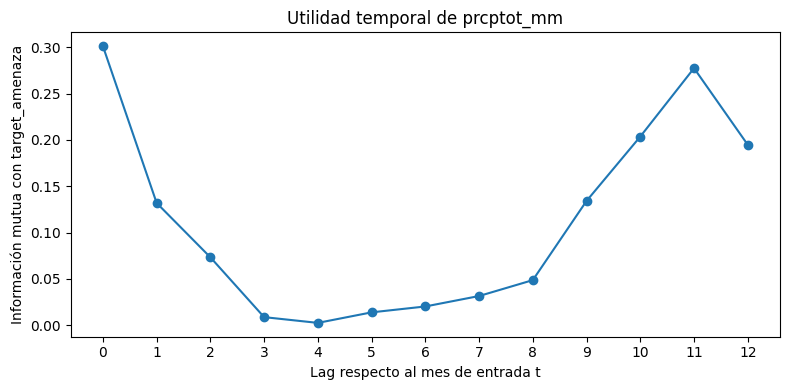

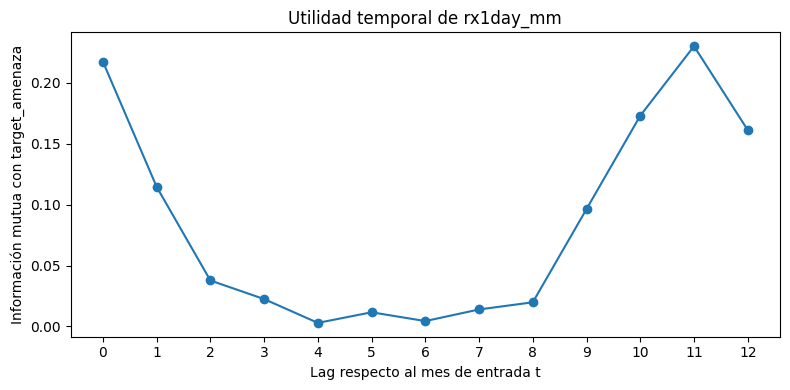

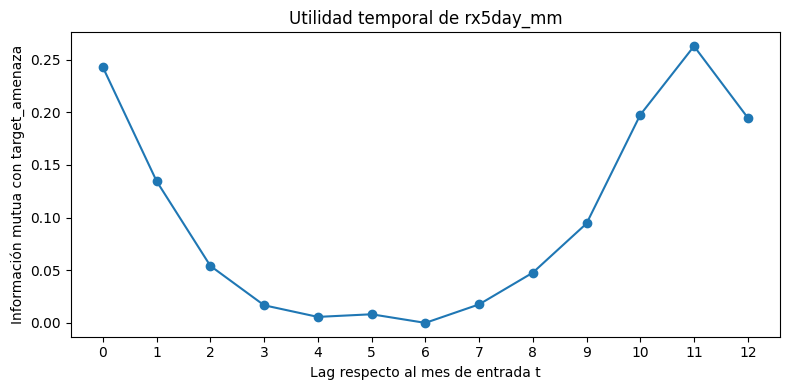

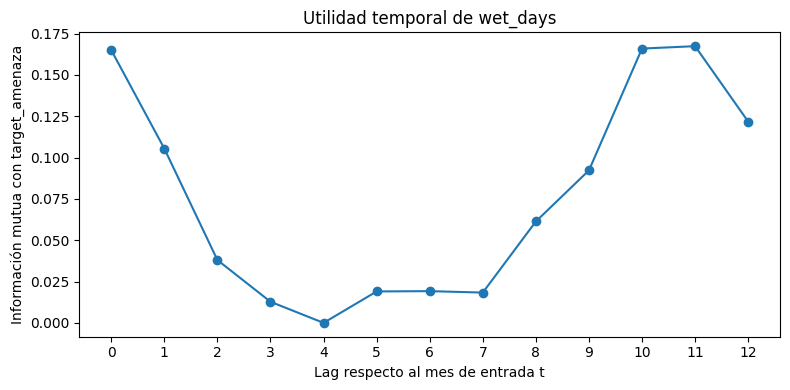

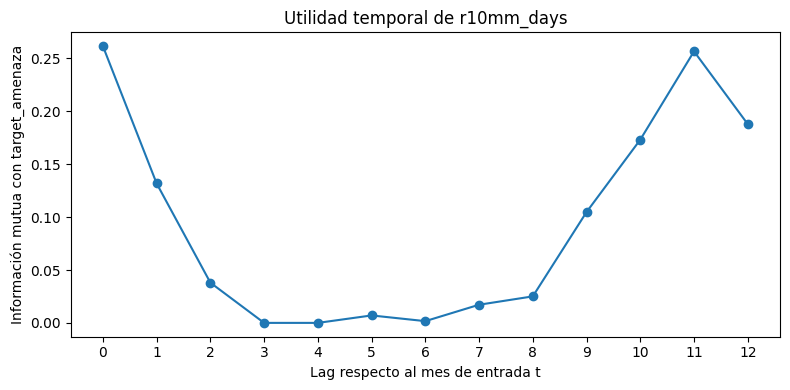

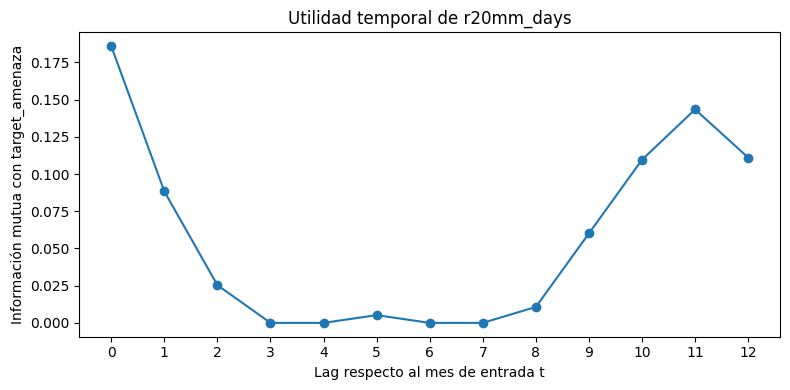

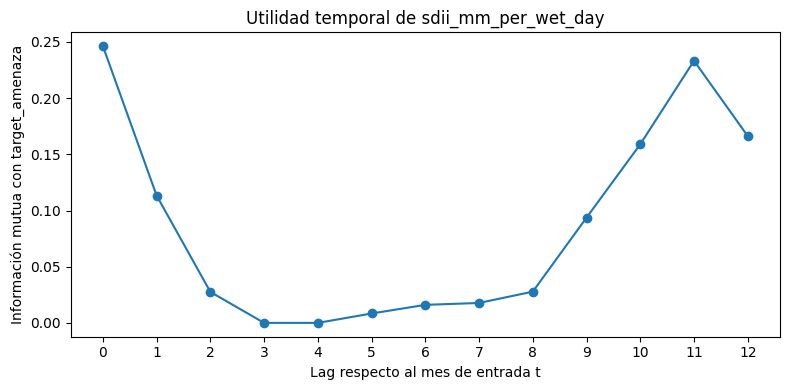

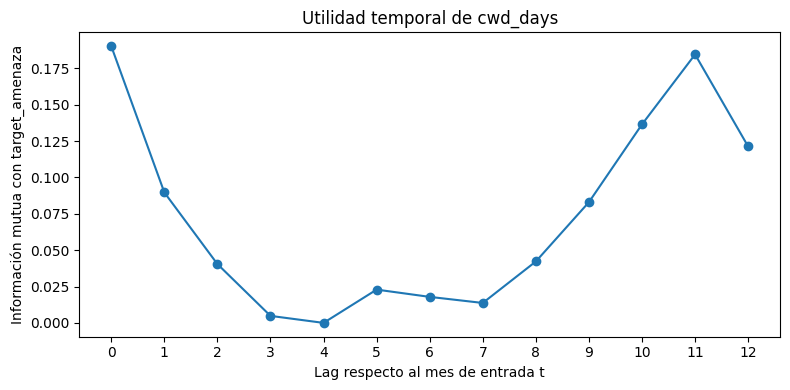

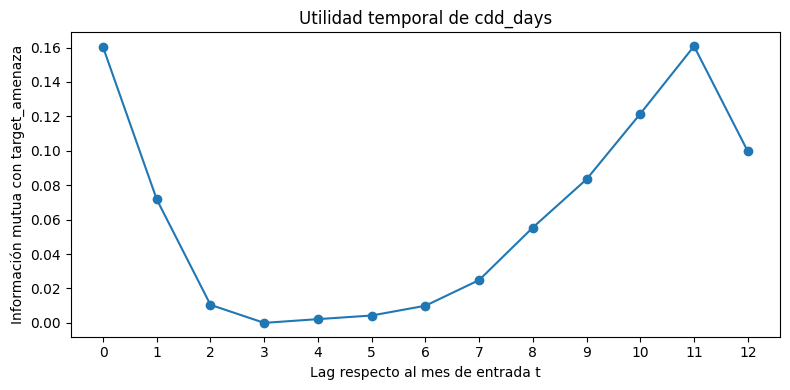

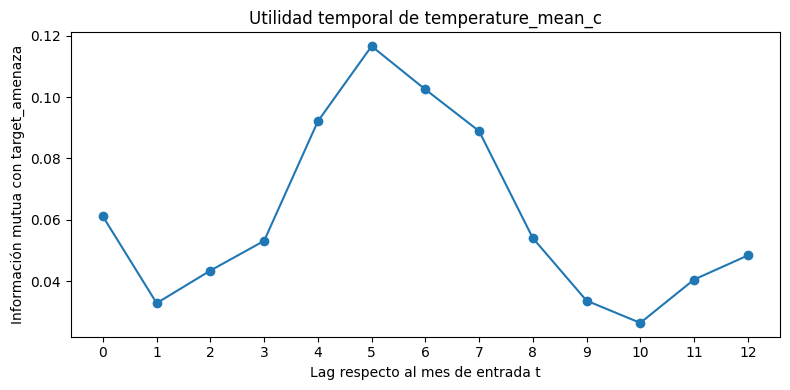

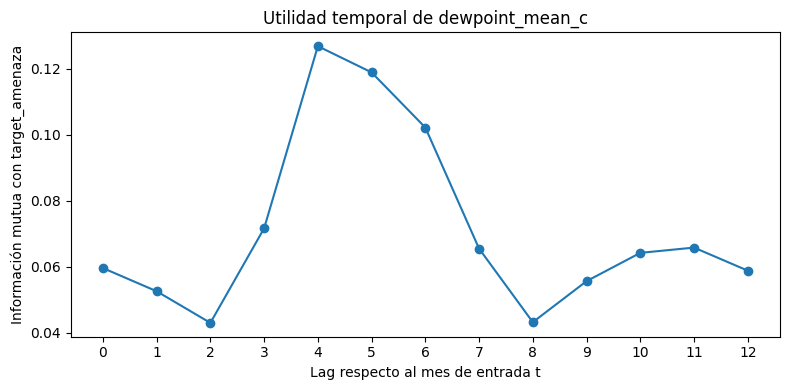

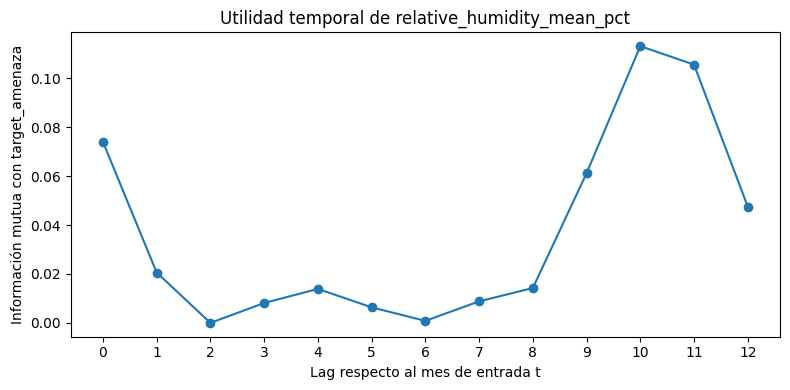

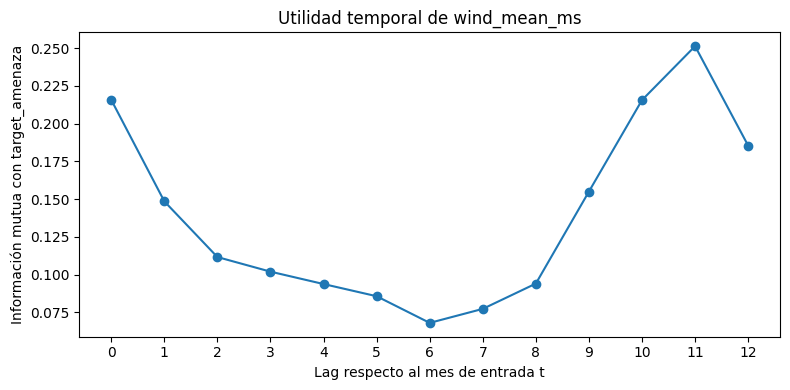

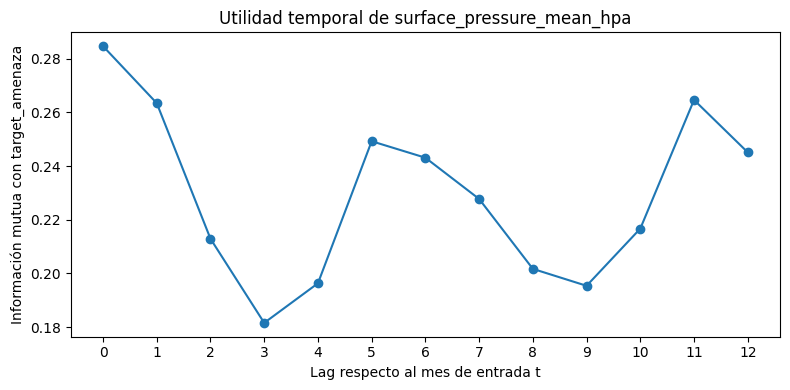

In [13]:

for feature in LAG_SOURCE_FEATURES:
    feature_data = lag_report[
        lag_report["variable"] == feature
    ]

    plt.figure(figsize=(8, 4))
    plt.plot(
        feature_data["lag"],
        feature_data["mutual_information_target_clase"],
        marker="o",
    )
    plt.xlabel("Lag respecto al mes de entrada t")
    plt.ylabel("Información mutua con target_amenaza")
    plt.title(f"Utilidad temporal de {feature}")
    plt.xticks(range(MAX_LAG + 1))
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"lag_mi_{feature}.png",
        dpi=140,
        bbox_inches="tight",
    )
    plt.show()



## 10. Contexto geográfico categórico

`region` se mantiene como candidata porque puede generalizar a zonas no vistas, a diferencia de `zone_id` o `ciudad`.

Aquí solo comprobamos su distribución y relación descriptiva con la clase futura. La codificación one-hot se hará **dentro del pipeline de modelado**, no aquí.


In [14]:

region_distribution = (
    train.groupby(
        ["region", "target_amenaza"],
        observed=True,
    )
    .size()
    .rename("cantidad")
    .reset_index()
)

region_distribution["porcentaje_dentro_region"] = (
    100
    * region_distribution["cantidad"]
    / region_distribution.groupby(
        "region",
        observed=True,
    )["cantidad"].transform("sum")
)

region_distribution.to_csv(
    OUTPUT_DIR / "distribucion_target_por_region.csv",
    index=False,
    encoding="utf-8-sig",
)

region_distribution


,region,target_amenaza,cantidad,porcentaje_dentro_region
0,Amazonía,Alta,355,54.953560
1,Amazonía,Baja,52,8.049536
2,Amazonía,Media,239,36.996904
3,Litoral,Alta,665,34.313725
4,Litoral,Baja,812,41.898865
5,Litoral,Media,461,23.787410
6,Sierra,Alta,299,23.142415
7,Sierra,Baja,415,32.120743
8,Sierra,Media,578,44.736842



## 11. Resumen automático del Paso 05

Este bloque no decide todavía la lista final de features. Resume los hallazgos que debemos revisar antes de construirla.


In [15]:

top_base = association_report.head(10)[
    [
        "caracteristica",
        "mutual_information_target_clase",
        "spearman_target_rx5day",
    ]
]

top_lags = lag_summary.head(10)[
    [
        "variable",
        "mejor_lag_mi",
        "mejor_mi",
        "mi_lag0",
        "mi_lag1",
        "mi_lag2",
        "mi_lag11",
    ]
]

print("TOP 10 · señal individual de características base")
display(top_base)

print("\nPares altamente correlacionados")
display(high_corr_report)

print("\nTOP 10 · variables según mejor lag observado")
display(top_lags)

print("\nArchivos generados en:")
print(OUTPUT_DIR.resolve())

print(
    "\nIMPORTANTE: todavía NO se ha entrenado ningún clasificador final "
    "y NO se ha usado validación/test para escoger características."
)


TOP 10 · señal individual de características base


,caracteristica,mutual_information_target_clase,spearman_target_rx5day
0,prcptot_mm,0.297862,0.728680
19,surface_pressure_mean_hpa,0.288963,-0.157580
7,r10mm_days,0.282404,0.694023
4,max_3h_mm,0.242805,0.665703
9,sdii_mm_per_wet_day,0.242441,0.673272
2,rx5day_mm,0.239812,0.703606
3,max_1h_mm,0.228151,0.654117
5,max_6h_mm,0.222542,0.663179
1,rx1day_mm,0.219374,0.670909
17,wind_mean_ms,0.217913,-0.610319



Pares altamente correlacionados


,caracteristica_1,caracteristica_2,spearman,abs_spearman
11,max_3h_mm,max_6h_mm,0.982656,0.982656
16,temperature_mean_c,temperature_min_c,0.972222,0.972222
5,rx1day_mm,max_6h_mm,0.964118,0.964118
18,temperature_min_c,dewpoint_mean_c,0.962862,0.962862
9,max_1h_mm,max_3h_mm,0.959511,0.959511
1,prcptot_mm,r10mm_days,0.954820,0.954820
17,temperature_mean_c,dewpoint_mean_c,0.952590,0.952590
0,prcptot_mm,rx5day_mm,0.944580,0.944580
4,rx1day_mm,max_3h_mm,0.937342,0.937342
13,wet_days,cdd_days,-0.933395,0.933395



TOP 10 · variables según mejor lag observado


,variable,mejor_lag_mi,mejor_mi,mi_lag0,mi_lag1,mi_lag2,mi_lag11
3,prcptot_mm,0,0.301158,0.301158,0.131881,0.073253,0.277411
10,surface_pressure_mean_hpa,0,0.284670,0.284670,0.263428,0.212904,0.264636
8,rx5day_mm,11,0.262893,0.242828,0.134578,0.054130,0.262893
4,r10mm_days,0,0.261622,0.261622,0.131809,0.038014,0.256705
13,wind_mean_ms,11,0.251345,0.215777,0.148580,0.111686,0.251345
9,sdii_mm_per_wet_day,0,0.246224,0.246224,0.113234,0.027539,0.233273
7,rx1day_mm,11,0.230011,0.217290,0.114578,0.037722,0.230011
1,cwd_days,0,0.190242,0.190242,0.089684,0.040441,0.184555
5,r20mm_days,0,0.185967,0.185967,0.088344,0.025363,0.143457
12,wet_days,11,0.167397,0.165004,0.105432,0.038013,0.167397



Archivos generados en:
C:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\analisis_caracteristicas

IMPORTANTE: todavía NO se ha entrenado ningún clasificador final y NO se ha usado validación/test para escoger características.



# Fin del Paso 05A

Con estos resultados se decidirán explícitamente:

1. qué variables base conservar;
2. qué grupos redundantes simplificar;
3. qué lags tienen evidencia suficiente;
4. si conviene añadir alguna transformación adicional;
5. cuál será el conjunto de **características candidatas** que pasará al pipeline de selección y modelado.

No se debe avanzar a los modelos hasta revisar estos reportes.
